In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import packages
import torch
from Index_Generators.ProbabilityGeneratorBlock import ProbabilityGeneratorBlock as PGB
import matplotlib.pyplot as plt

In [3]:
# Build a probability generator block
MyPGB = PGB(input_size=1, num_categories=10, hidden_size=128, num_layers=3, weight=None, conditioning_input_size=0)

In [8]:
# Run the model
N = 100
input = torch.arange(1,N+1).reshape(N,1).float()
index, log_probability, entropy = MyPGB(input)
print('Input shape:', input.shape)
print('Output Index shape:', index.shape)
print('Output Log Probability shape:', log_probability.shape)
print('Output Entropy shape:', entropy.shape)

Input shape: torch.Size([100, 1])
Output Index shape: torch.Size([100])
Output Log Probability shape: torch.Size([100])
Output Entropy shape: torch.Size([100])


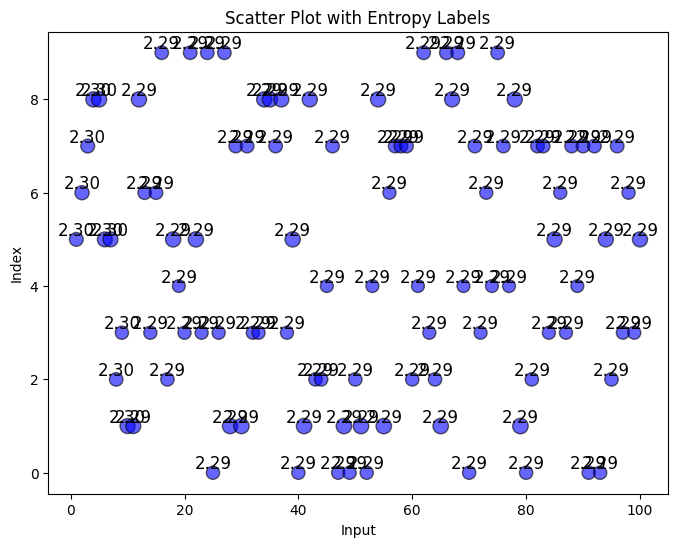

In [9]:
# Plot the results
x = input.detach()
y = index.detach()
sizes = torch.exp(log_probability.detach()) * 1000  
labels = entropy.detach()
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=sizes, color='blue', alpha=0.6, edgecolors='black')
for x, y, e in zip(input, index, entropy):
    plt.text(x, y, f"{e:.2f}", fontsize=12, ha='center', va='bottom')
plt.xlabel("Input")
plt.ylabel("Index")
plt.title("Scatter Plot with Entropy Labels")
plt.show()
